Matplotlib is building the font cache; this may take a moment.


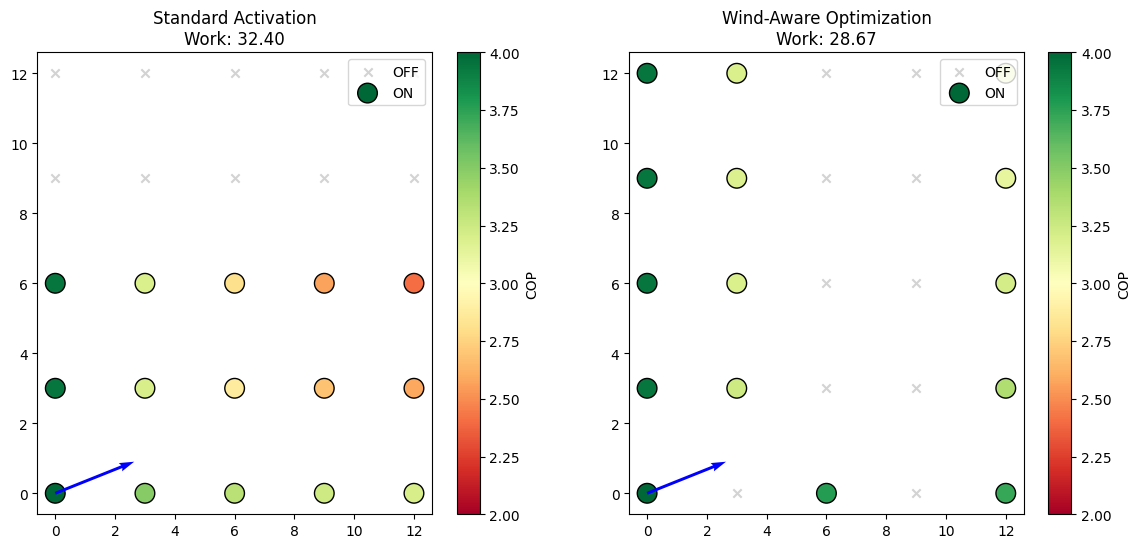

Efficiency Improvement: 11.52%


In [1]:
# %% [markdown]
# # Chiller Array Efficiency Optimizer
# This notebook implements a physics-based model for chiller performance 
# in a data center array, accounting for thermal recirculation caused by wind.

# %%
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class ChillerEnvironment:
    """
    Simulates the thermal interference between chillers based on 
    spatial positioning and wind vectors.
    """
    def __init__(self, positions, wind_vec, base_cop=4.0, alpha=0.7):
        self.positions = np.array(positions)
        self.wind_vec = np.array(wind_vec) / np.linalg.norm(wind_vec)
        self.base_cop = base_cop
        self.alpha = alpha  # Sensitivity to heat intake
        self.num_chillers = len(positions)
        self.A = self._calculate_interference_matrix()

    def _calculate_interference_matrix(self):
        """Builds the coupling matrix A[k, m] where k affects m."""
        A = np.zeros((self.num_chillers, self.num_chillers))
        for k in range(self.num_chillers):
            for m in range(self.num_chillers):
                if k == m: continue
                d_km = self.positions[m] - self.positions[k]
                long_dist = np.dot(d_km, self.wind_vec)
                
                if long_dist > 0: # Only downwind units are affected
                    lateral_dist = np.linalg.norm(d_km - long_dist * self.wind_vec)
                    # Gaussian dispersion model
                    influence = np.exp(-(lateral_dist**2) / (1.2 * (long_dist + 1))) / (long_dist + 1)
                    A[k, m] = influence
        return A

    def get_performance(self, state, total_load):
        """Calculates total energy work required for a given on/off state."""
        active_mask = (state == 1)
        n_active = np.sum(state)
        if n_active == 0: return float('inf'), np.zeros(self.num_chillers)
        
        q_per_unit = total_load / n_active
        t_rise = np.dot(state, self.A)
        cops = self.base_cop / (1 + self.alpha * t_rise)
        
        # Work = sum(Load / COP)
        total_work = np.sum(q_per_unit / cops[active_mask])
        return total_work, cops

# %% [markdown]
# ## 1. Initialization
# Setting up a 5x5 grid and a prevailing North-East wind.

# %%
grid_side = 5
x, y = np.meshgrid(np.linspace(0, 12, grid_side), np.linspace(0, 12, grid_side))
positions = np.vstack([x.ravel(), y.ravel()]).T
wind = [1.0, 0.4]

env = ChillerEnvironment(positions, wind)
TOTAL_LOAD = 100
TARGET_UNITS = 15

# %% [markdown]
# ## 2. Standard vs. Optimized Comparison

# %%
# Standard: First 15 chillers in the list
state_std = np.zeros(25)
state_std[:TARGET_UNITS] = 1
work_std, cops_std = env.get_performance(state_std, TOTAL_LOAD)

# Optimized: Greedy Removal Strategy
state_opt = np.ones(25)
while np.sum(state_opt) > TARGET_UNITS:
    candidates = np.where(state_opt == 1)[0]
    best_to_remove = -1
    min_work = float('inf')
    
    for idx in candidates:
        test_state = state_opt.copy()
        test_state[idx] = 0
        w, _ = env.get_performance(test_state, TOTAL_LOAD)
        if w < min_work:
            min_work = w
            best_to_remove = idx
    state_opt[best_to_remove] = 0

work_opt, cops_opt = env.get_performance(state_opt, TOTAL_LOAD)

# %% [markdown]
# ## 3. Visualizing Results

# %%
def plot_results(state, cops, title, work):
    plt.scatter(positions[state==0, 0], positions[state==0, 1], c='lightgrey', marker='x', label='OFF')
    sc = plt.scatter(positions[state==1, 0], positions[state==1, 1], c=cops[state==1], 
                     cmap='RdYlGn', s=200, edgecolor='k', vmin=2, vmax=4, label='ON')
    plt.title(f"{title}\nWork: {work:.2f}")
    plt.colorbar(sc, label='COP')
    plt.quiver(0, 0, wind[0], wind[1], color='blue', scale=5)
    plt.legend()

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1); plot_results(state_std, cops_std, "Standard Activation", work_std)
plt.subplot(1, 2, 2); plot_results(state_opt, cops_opt, "Wind-Aware Optimization", work_opt)
plt.show()

print(f"Efficiency Improvement: {((work_std - work_opt)/work_std)*100:.2f}%")

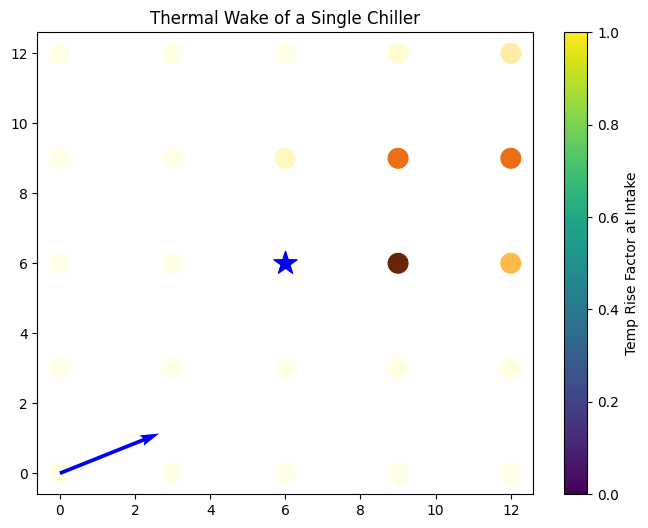

In [2]:
# %% [markdown]
# ### Demo 1: Visualizing a Single Thermal Plume
# Before optimizing the array, we visualize how one chiller (The Source) 
# contaminates the air for everyone else.

# %%
def demo_single_plume():
    # Place one chiller at (5,5) and others in a grid
    source_idx = 12 # Middle of the 5x5
    state_single = np.zeros(25)
    state_single[source_idx] = 1
    
    # Calculate impact of ONLY this chiller
    thermal_impact = env.A[source_idx, :]
    
    plt.figure(figsize=(8, 6))
    plt.scatter(positions[:, 0], positions[:, 1], c=thermal_impact, cmap='YlOrBr', s=200)
    plt.scatter(positions[source_idx, 0], positions[source_idx, 1], c='blue', s=300, marker='*', label='Source')
    plt.title("Thermal Wake of a Single Chiller")
    plt.colorbar(label='Temp Rise Factor at Intake')
    plt.quiver(0, 0, wind[0], wind[1], color='blue', scale=5)
    plt.show()

demo_single_plume()

In [3]:
# %% [markdown]
# ### Demo 2: The Penalty of Density
# Here we calculate the COP of a chiller when it is alone vs. when it is 
# surrounded by 24 other active units.

# %%
# Case A: Solo Chiller
state_solo = np.zeros(25); state_solo[12] = 1
_, cops_solo = env.get_performance(state_solo, 10)

# Case B: Full Array
state_full = np.ones(25)
_, cops_full = env.get_performance(state_full, 250)

print(f"Isolated Chiller COP: {cops_solo[12]:.2f}")
print(f"Crowded Chiller COP (Middle): {cops_full[12]:.2f}")
print(f"Efficiency Loss due to surrounding units: {((cops_solo[12] - cops_full[12])/cops_solo[12])*100:.1f}%")

Isolated Chiller COP: 4.00
Crowded Chiller COP (Middle): 2.80
Efficiency Loss due to surrounding units: 30.1%


In [4]:
# %% [markdown]
# ### Demo 3: The 'Less is More' Optimization
# We simulate a scenario where we have 100 units of heat to dissipate. 
# We compare:
# 1. Running all 25 chillers (Low load per unit, but high interference).
# 2. Running 15 optimized chillers (Higher load per unit, but clean air).

# %%
work_25, _ = env.get_performance(np.ones(25), 100)
work_15_opt, _ = env.get_performance(state_opt, 100) # state_opt from earlier greedy search

print(f"Energy used by 25 chillers: {work_25:.2f}")
print(f"Energy used by 15 optimized chillers: {work_15_opt:.2f}")

Energy used by 25 chillers: 33.43
Energy used by 15 optimized chillers: 28.67


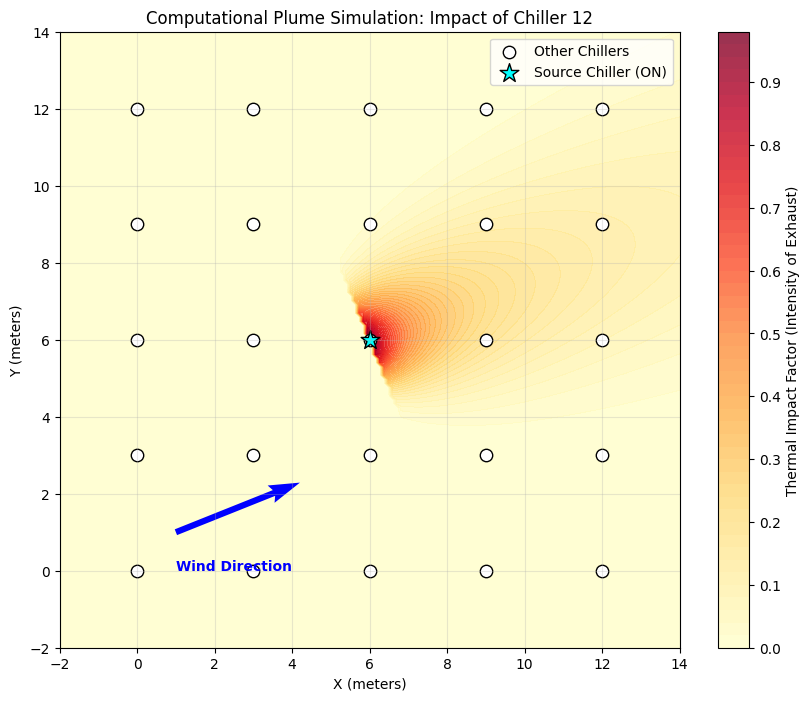

In [5]:
# %% [markdown]
# ### Demo: High-Resolution Computational Wake Analysis
# This demo calculates the continuous thermal field generated by a single source. 
# It demonstrates the "Gaussian Plume" physics that dictates the interference matrix $A$.

# %%
def plot_high_res_wake(source_index=12, res=150):
    # 1. Setup the source and wind
    source_pos = positions[source_index]
    wind_v = np.array(wind)
    w_hat = wind_v / np.linalg.norm(wind_v)
    
    # 2. Create a dense grid for the heatmap
    x_range = np.linspace(-2, 14, res)
    y_range = np.linspace(-2, 14, res)
    X, Y = np.meshgrid(x_range, y_range)
    Z = np.zeros_like(X)
    
    # 3. Compute interference at every pixel
    for i in range(res):
        for j in range(res):
            target = np.array([X[i, j], Y[i, j]])
            dist_vec = target - source_pos
            long_dist = np.dot(dist_vec, w_hat)
            
            if long_dist > 0:
                lateral_vec = dist_vec - long_dist * w_hat
                lateral_dist = np.linalg.norm(lateral_vec)
                # Apply Gaussian Plume Dispersion
                Z[i, j] = np.exp(-(lateral_dist**2) / (1.2 * (long_dist + 1))) / (long_dist + 1)

    # 4. Visualize
    plt.figure(figsize=(10, 8))
    cp = plt.contourf(X, Y, Z, levels=50, cmap='YlOrRd', alpha=0.8)
    plt.colorbar(cp, label='Thermal Impact Factor (Intensity of Exhaust)')
    
    # Overlay the chiller array
    plt.scatter(positions[:, 0], positions[:, 1], c='white', edgecolors='black', s=80, label='Other Chillers')
    plt.scatter(source_pos[0], source_pos[1], c='cyan', s=200, marker='*', edgecolor='black', label='Source Chiller (ON)')
    
    # Add wind direction arrow
    plt.quiver(1, 1, wind_v[0], wind_v[1], color='blue', scale=5, width=0.01)
    plt.text(1, 0, "Wind Direction", color='blue', fontweight='bold')
    
    plt.title(f"Computational Plume Simulation: Impact of Chiller {source_index}")
    plt.xlabel("X (meters)")
    plt.ylabel("Y (meters)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# Run the demo for the center chiller
plot_high_res_wake(source_index=12)